In [8]:
import numpy as np

import seaborn as sns


In [6]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("../data/raw_data/nigeria (1).csv")

In [14]:
df["country"]="Nigeria"
df["date"]=pd.to_datetime(df["YEAR"]*1000+df["DOY"], format="%Y%j")
df["Month"]=df["date"].dt.month

In [15]:
df.replace(-999, np.nan, inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [16]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


Although temperature and the other variables have relatively close mean and median values, PRECTOTCORR shows a noticeable difference, with a mean of **3.8 mm/day** and a median of **1.8 mm/day**. This indicates that the precipitation distribution is **right-skewed**, with most days receiving relatively low rainfall and a smaller number of days receiving much higher rainfall. The standard deviation of **7 mm/day** also indicates considerable variability in precipitation, showing that rainfall amounts vary substantially from day to day.


In [17]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
country        0
date           0
Month          0
dtype: int64

In [18]:
missing_percentage=df.isna().mean()*100

In [19]:
missing_percentage[missing_percentage>5]

Series([], dtype: float64)

In [20]:
cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

In [21]:
Z_score=(df[cols]-df[cols].mean())/df[cols].std()

In [22]:
outlier_rows=(Z_score.abs()>3).any(axis=1)

### Outlier Treatment

The identified outlier rows will be **retained** rather than dropped or capped. A z-score greater than 3 indicates that an observation is unusually far from the mean, but it does not necessarily mean that the observation is an error. Since this is climate data, extreme temperatures, rainfall, humidity, or wind speeds may represent genuine weather events and are relevant to climate analysis.

Dropping these observations could remove important extreme events from the dataset, while capping them would change their original values and potentially reduce the observed severity of extreme conditions. Therefore, the outliers are retained and flagged for further analysis rather than automatically treating them as errors.


In [23]:
outlier_rows.sum()

np.int64(225)

In [24]:
row_missing_percentage = df.isna().mean(axis=1) * 100

In [25]:
df=df[row_missing_percentage<=30]

In [26]:
df.to_csv("../data/processed_data/nigeria_clean.csv", index=False)

In [27]:
monthly_T2M=df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

In [28]:
monthly_T2M["date"]=pd.to_datetime(
    monthly_T2M["YEAR"].astype(str)+"-"+monthly_T2M["Month"].astype(str)+"-01"
)

In [29]:
peak_tempMAX=monthly_T2M.loc[monthly_T2M["T2M"].idxmax()]

In [30]:
peak_tempMIN=monthly_T2M.loc[monthly_T2M["T2M"].idxmin()]

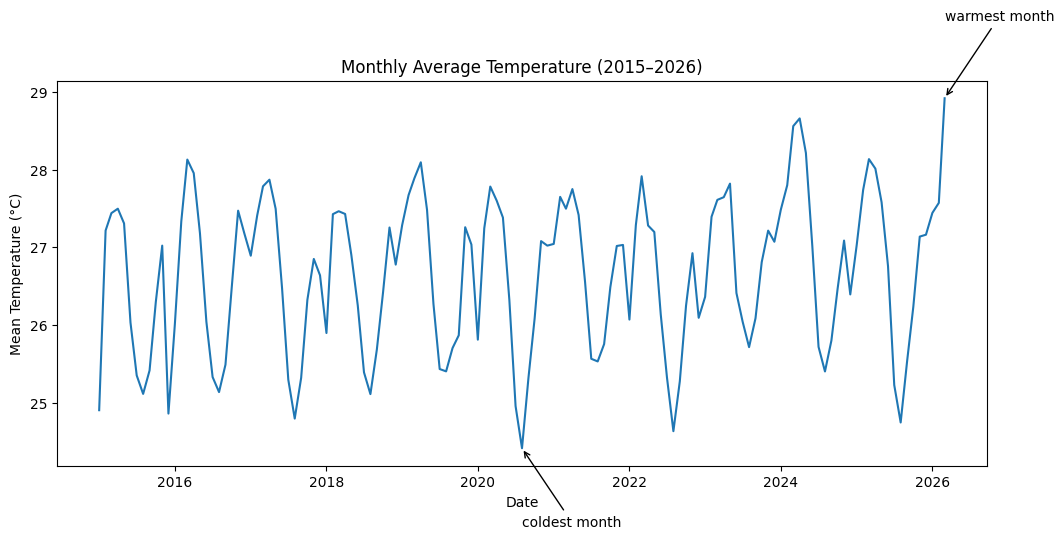

In [32]:
plt.figure(figsize=(12,5))
plt.plot(monthly_T2M["date"], monthly_T2M["T2M"])
plt.annotate(
    "warmest month",
    xy=(peak_tempMAX["date"], peak_tempMAX["T2M"]),
    xytext=(peak_tempMAX["date"], peak_tempMAX["T2M"]+1),
    arrowprops=dict(arrowstyle="->")
)
plt.annotate(
    "coldest month",
    xy=(peak_tempMIN["date"], peak_tempMIN["T2M"]),
    xytext=(peak_tempMIN["date"], peak_tempMIN["T2M"]-1),
    arrowprops=dict(arrowstyle="->")
)
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Monthly Average Temperature (2015–2026)")

plt.show()

The temperature pattern throughout the years appears relatively stable, without a clear increase or decrease and without large fluctuations. The mean temperature also appears to remain relatively consistent across the period, suggesting that there is no major change in the overall temperature pattern over time.


In [34]:
monthly_prec=df.groupby(["Month"])["PRECTOTCORR"].sum().reset_index()

In [36]:
peak_prec=monthly_prec.loc[monthly_prec["PRECTOTCORR"].idxmax()]

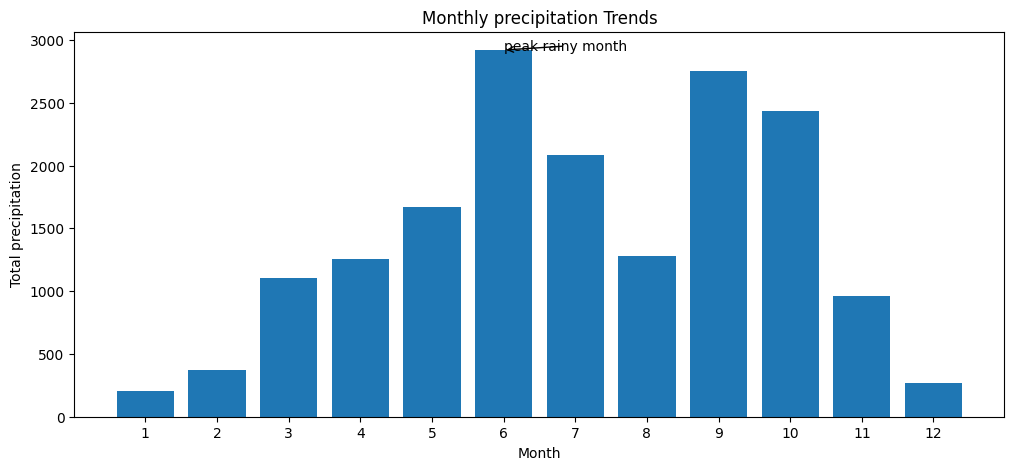

In [39]:
plt.figure(figsize=(12,5))
plt.bar(monthly_prec["Month"],monthly_prec["PRECTOTCORR"])
plt.annotate(
    "peak rainy month",
    xy=(peak_prec["Month"], peak_prec["PRECTOTCORR"]),
    xytext=(peak_prec["Month"], peak_prec["PRECTOTCORR"]),
    arrowprops=dict(arrowstyle="->")
    
)
plt.xlabel("Month")
plt.ylabel("Total precipitation")
plt.title("Monthly precipitation Trends")
plt.xticks(range(1, 13))
plt.show()

Overall, the country experiences rainfall throughout much of the year. Although July receives considerably more precipitation than the other months, no month appears to be completely dry. Months 3 through 10 show particularly prominent rainfall, indicating that precipitation is relatively widespread across the year, with July representing the peak rainy period.


In [40]:
number=df.select_dtypes(include="number")

In [41]:
correlation=number.corr()

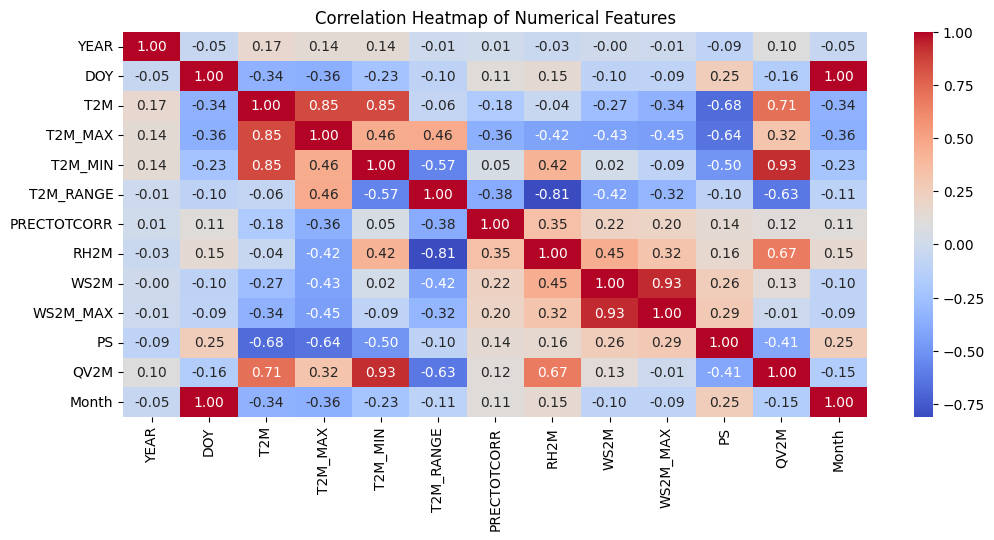

In [43]:
plt.figure(figsize=(12,5))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation heatmap shows a **strong positive correlation of 0.93 between T2M and QV2M**, indicating that higher air temperatures are strongly associated with higher specific humidity.

QV2M and RH2M also show a **positive correlation of 0.67**, suggesting a moderate-to-strong positive relationship between specific humidity and relative humidity.

In contrast, RH2M and T2M_RANGE have a **strong negative correlation of -0.81**, indicating that higher relative humidity is generally associated with a smaller daily temperature range.

Overall, the heatmap shows strong relationships among temperature, humidity, and daily temperature range variables.


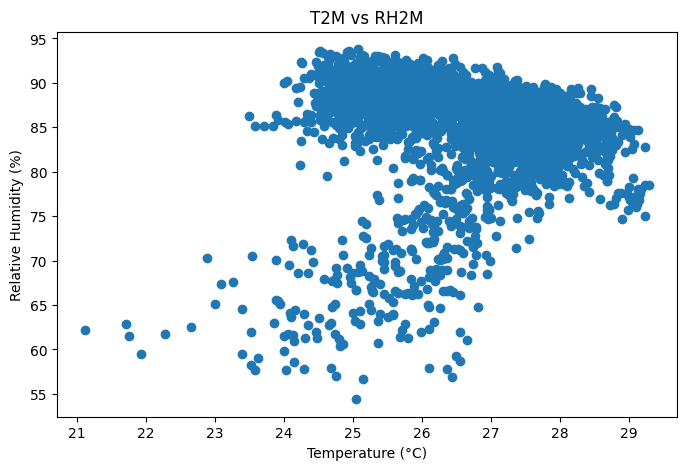

In [44]:
plt.figure(figsize=(8, 5))

plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")

plt.show()

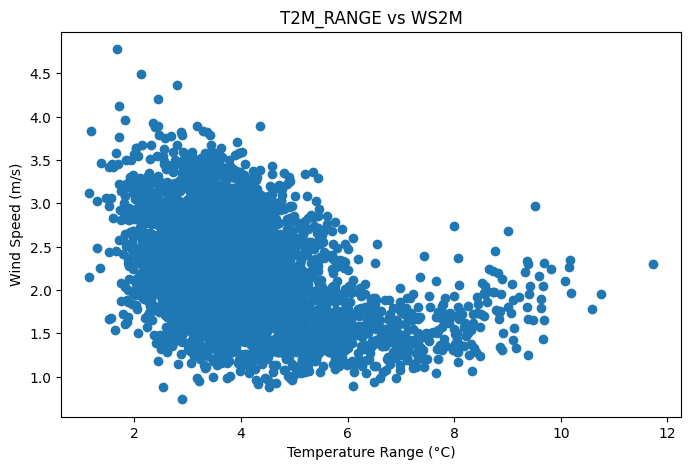

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Wind Speed (m/s)")
plt.title("T2M_RANGE vs WS2M")
plt.show()

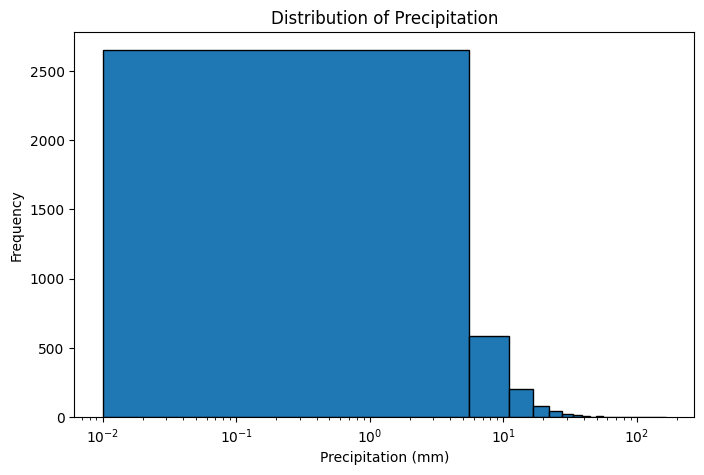

In [46]:
rain=df.loc[df["PRECTOTCORR"]>0, "PRECTOTCORR"]
plt.figure(figsize=(8,5))
plt.hist(rain, bins=30, edgecolor="black")
plt.xscale("log")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.title("Distribution of Precipitation")
plt.show()

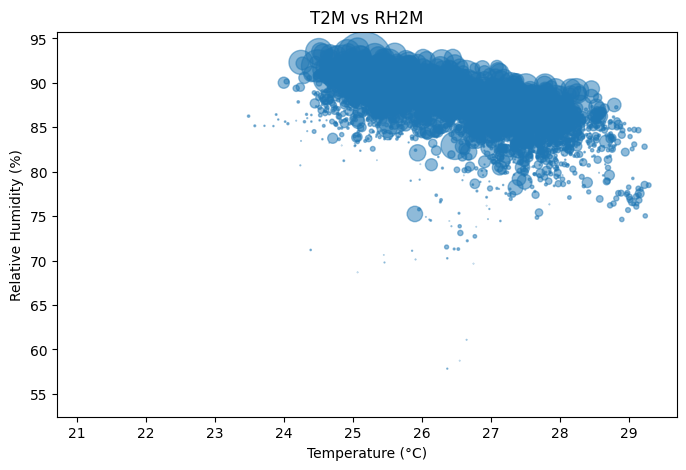

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"],df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5 )
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("T2M vs RH2M")
plt.show()